## Detecting outliers and adapting models to these

In [4]:
import time
import os
import math
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

from pinard import utils
from pinard import preprocessing as pp
from pinard.model_selection import train_test_split_idx

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.linear_model import RidgeCV, LinearRegression
from xgboost import XGBRegressor


# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
simplefilter(action='ignore', category=UserWarning)

### Importation of the datasets

In [11]:
# Function to load a CSV file with automatic separator detection

def load_csv_auto_sep(path):
    with open(path, 'r', newline='', encoding='utf-8') as f:
        # Read a small portion of the file to detect the separator
        excerpt = f.read(1024)
        f.seek(0)  # return to the beginning of the file

        # Detection of the dialect
        dialect = csv.Sniffer().sniff(excerpt)
        sep = dialect.delimiter

        print("Detected separator : %s" % sep)
        
        # Load the file with pandas
        df = pd.read_csv(f, delimiter=sep)
        return df

In [47]:
mode = 'Regression' # 'Classification' or 'Regression'
 
## Choose the source of data to be imported
# Regression: 'BeerOriginalExtract' or 'Digest_0.8' or 'YamProtein' //
# Classification: 'CoffeeSpecies' or 'Malaria2024' or 'mDigest_custom3' or 'WhiskyConcentration' or 'YamMould'
data_source = 'BeerOriginalExtract' 


## Importation of the datasets with the adapted path
file_name = Path("Data/%s/%s"% (mode,data_source))
full_path = str(file_name.resolve()).replace("\\", "/")

Xcal = load_csv_auto_sep(f'{full_path}/Xcal.csv')
Xval = load_csv_auto_sep(f'{full_path}/Xval.csv')
Ycal = load_csv_auto_sep(f'{full_path}/Ycal.csv')
Yval = load_csv_auto_sep(f'{full_path}/Yval.csv')

print("Number of spectra for calibration: ", len(Ycal))
print("Number of spectra for test: ", len(Yval))
display(Xcal.head(5))

Detected separator : ;
Detected separator : ;
Detected separator : 
Detected separator : 
Number of spectra for calibration:  40
Number of spectra for test:  20


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V567,V568,V569,V570,V571,V572,V573,V574,V575,V576
0,0.245288,0.251593,0.258437,0.265449,0.272342,0.280249,0.288323,0.297118,0.307861,0.319456,...,3.679895,3.654557,3.653983,3.714209,3.669642,3.625521,3.647152,3.573585,3.623088,3.679775
1,0.242613,0.248841,0.255609,0.262486,0.269311,0.277092,0.285063,0.293715,0.304371,0.315839,...,3.632740,3.738945,3.601677,3.592955,3.606268,3.657218,3.632019,3.660901,3.635919,3.671539
2,0.241651,0.247774,0.254431,0.261214,0.267891,0.275535,0.283370,0.291886,0.302335,0.313625,...,3.563812,3.622122,3.617598,3.652315,3.590150,3.710362,3.630672,3.653063,3.566837,3.704355
3,0.239650,0.245743,0.252350,0.259107,0.265761,0.273390,0.281214,0.289725,0.300164,0.311455,...,3.583575,3.620621,3.682378,3.681044,3.650404,3.645983,3.633222,3.668727,3.650432,3.687260
4,0.240787,0.246900,0.253521,0.260278,0.266935,0.274576,0.282420,0.290953,0.301394,0.312720,...,3.650906,3.728940,3.614735,3.618842,3.656746,3.622961,3.560679,3.710902,3.653769,3.663029


### Construction of the pipelines

In [48]:
rd_seed = 42
rd_seed = np.random.seed(rd_seed)

x, y = pd.concat([Xcal,Xval], axis=0).values, pd.concat([Ycal,Yval], axis=0).values

### Declare preprocessing methods that will be used
preprocessing = [   ('id', pp.IdentityTransformer()),
                    ('baseline', pp.Baseline()),
                    ('derivate', pp.Derivate()),
                    ('detrend', pp.Detrend()),
                    ('MSC', pp.MultiplicativeScatterCorrection()),
                    ('normalize', pp.Normalize()),
                    ('RNV', pp.RobustNormalVariate()),
                    ('savgol', pp.SavitzkyGolay()),
                    ('simplescale', pp.SimpleScale()),
                    ('SNV', pp.StandardNormalVariate()),
                    ('haar', pp.Wavelet('haar')),
                    ('gaussian', pp.Gaussian(order = 2, sigma = 1)),
                    ('PCA', PCA())
                ]

# Apply the preprocessing methods to the calibration dataset
transformed_datasets = {}
for name, method in preprocessing:
    x = method.fit_transform(Xcal)
    transformed_datasets[name] = x

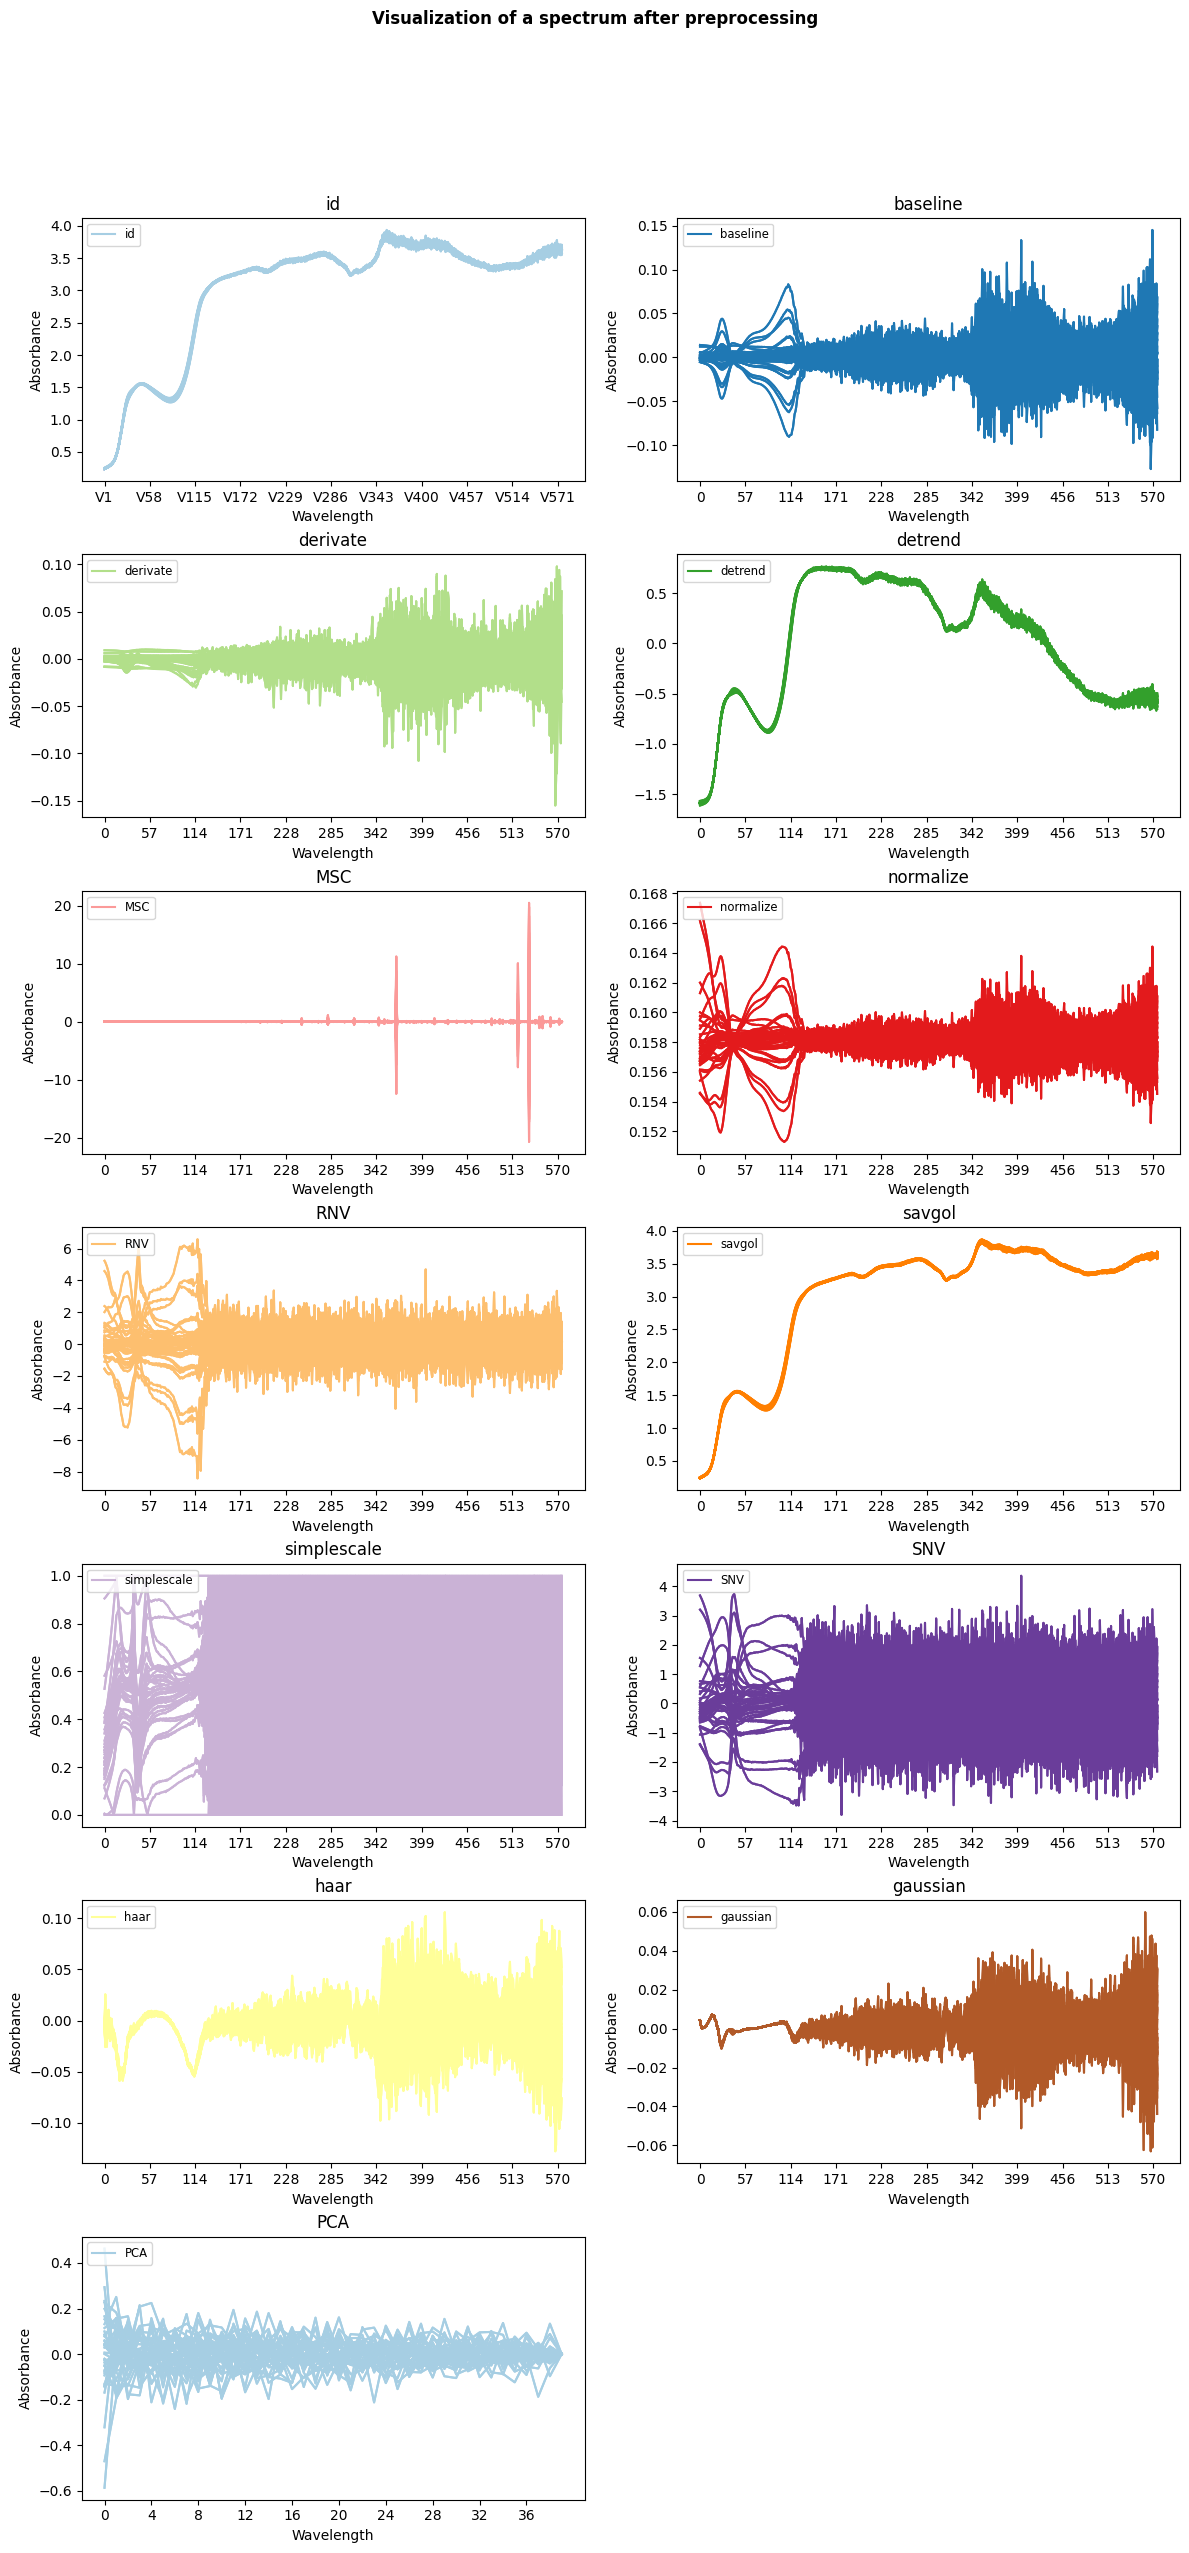

In [49]:
def plot_spectra(X, names, title='Visualization of the spectra'):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(12, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    colors = sns.color_palette("Paired", len(X))
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            dataset = X[i]
            ax.set_title(names[i])
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color=colors[i])
            ax.legend(loc='upper left', fontsize='small')
            ax.plot(dataset.T, color=colors[i])
            ax.plot([], [], color=colors[i], label=names[i])
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    plt.show(block=False)

# Plot the spectra
plot_spectra(list(transformed_datasets.values()), 
             names = list(transformed_datasets.keys()), 
             title= 'Visualization of a spectrum after preprocessing')
plt.show()